In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/casos_dengue_2020-2025.csv"
df = pd.read_csv(ruta)

df

,FECHA,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,COAHUILA,COLIMA,DISTRITO FEDERAL,...,QUINTANA ROO,SAN LUIS POTOSI,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATAN,ZACATECAS
0,2020-01-05,0,2,4,36,41,1,4,23,6,...,106,47,40,8,112,111,0,249,58,3
1,2020-01-12,0,2,3,37,83,5,1,37,6,...,167,74,46,13,158,206,0,441,62,0
2,2020-01-19,0,0,3,31,73,0,4,40,2,...,158,80,48,12,166,190,0,412,73,2
3,2020-01-26,1,1,2,45,57,0,1,39,3,...,130,53,54,13,167,191,1,418,54,1
4,2020-02-02,0,0,2,40,54,0,1,32,0,...,99,43,48,9,139,173,1,322,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,2025-04-27,3,3,11,24,72,0,13,30,9,...,79,36,36,7,84,100,0,245,50,0
278,2025-05-04,9,2,8,27,93,0,3,37,4,...,92,36,37,9,82,76,0,206,42,0
279,2025-05-11,2,1,17,24,102,0,7,45,4,...,114,46,25,13,91,125,0,296,54,1
280,2025-05-18,10,3,15,14,105,1,9,42,5,...,93,37,31,13,110,103,1,331,58,0


In [47]:
cols_municipios = ['AGUASCALIENTES', 'BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR',
       'CAMPECHE', 'CHIAPAS', 'CHIHUAHUA', 'COAHUILA', 'COLIMA',
       'DISTRITO FEDERAL', 'DURANGO', 'GUANAJUATO', 'GUERRERO', 'HIDALGO',
       'JALISCO', 'MEXICO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'NUEVO LEON',
       'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SAN LUIS POTOSI',
       'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'TLAXCALA', 'VERACRUZ',
       'YUCATAN', 'ZACATECAS']

In [48]:

df["FECHA"] = pd.to_datetime(df["FECHA"])

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df = df[["FECHA", "casos_semana"]].copy()

df = df.rename(columns={'FECHA': 'semana'})

print("Nuevo tamaño del DataFrame:", df.shape)
print(df.head())

Nuevo tamaño del DataFrame: (282, 2)
      semana  casos_semana
0 2020-01-05          1318
1 2020-01-12          2068
2 2020-01-19          2078
3 2020-01-26          1973
4 2020-02-02          1562


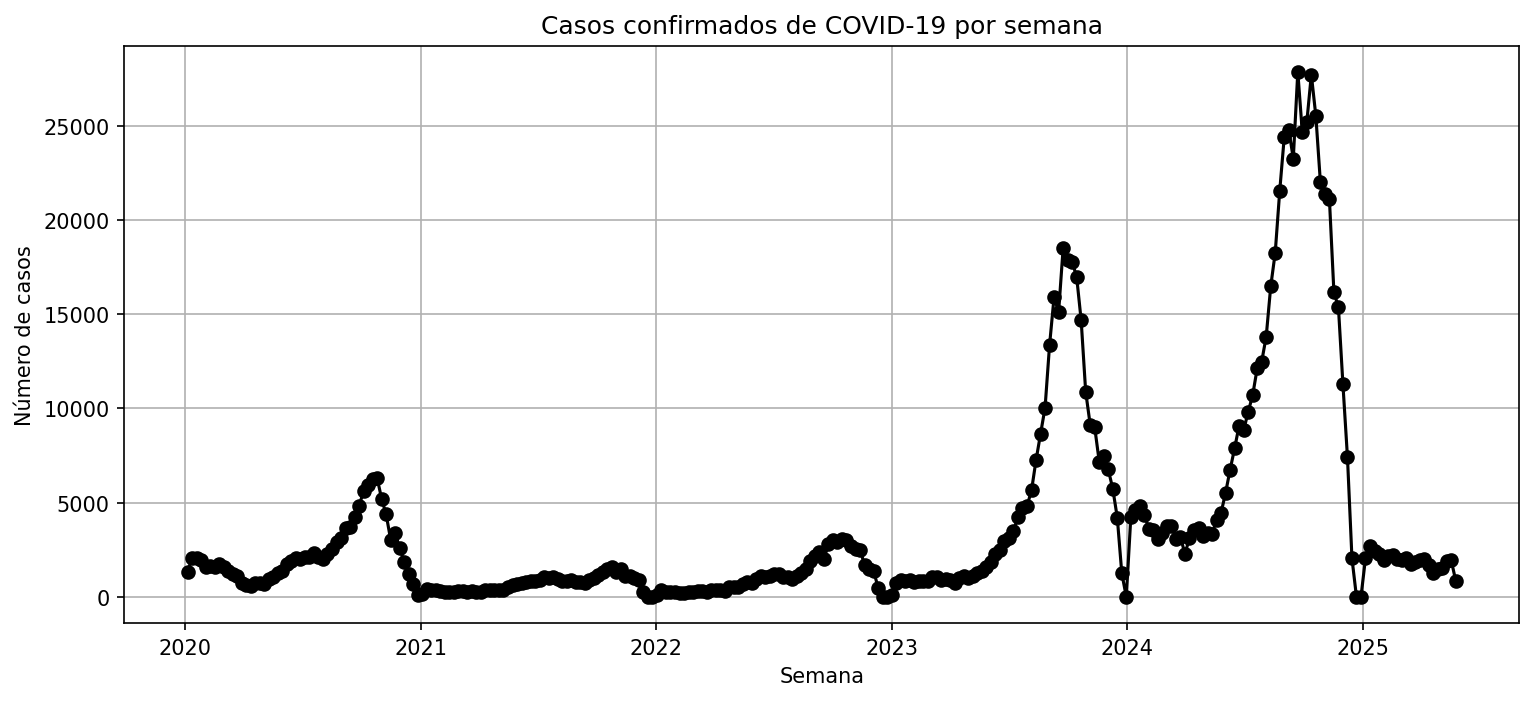

In [49]:

plt.figure(figsize=(12, 5), dpi=150)

plt.plot(
    df['semana'],
    df["casos_semana"],
    marker="o",
    color="black")

plt.xlabel("Semana")
plt.ylabel("Número de casos")
plt.title("Casos confirmados de COVID-19 por semana")

plt.grid()

plt.show()

In [50]:
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)
df["lag_4"] = df["casos_semana"].shift(4)

df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df["cambio_semanal"] = df["casos_semana"].diff()

df["cambio_relativo"] = (
    df["casos_semana"] - df["lag_1"]
) / df["lag_1"]

df["cambio_relativo"] = df["cambio_relativo"].replace(
    [np.inf, -np.inf],
    np.nan
)


In [51]:
df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df.head(10)

,semana,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,cambio_relativo,casos_siguiente_semana
0,2020-01-05,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2068.0
1,2020-01-12,2068,1318.0,NaN,NaN,NaN,NaN,NaN,750.0,0.569044,2078.0
2,2020-01-19,2078,2068.0,1318.0,NaN,NaN,1821.333333,NaN,10.0,0.004836,1973.0
3,2020-01-26,1973,2078.0,2068.0,1318.0,NaN,2039.666667,NaN,-105.0,-0.050529,1562.0
4,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,-411.0,-0.208312,1659.0
5,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,97.0,0.062100,1593.0
6,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,-66.0,-0.039783,1756.0
7,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,163.0,0.102323,1598.0
8,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,-158.0,-0.089977,1384.0
9,2020-03-08,1384,1598.0,1756.0,1593.0,1659.0,1579.333333,1598.0,-214.0,-0.133917,1200.0


In [52]:
df["riesgo_siguiente_semana"], cortes = pd.qcut(
    df["casos_siguiente_semana"],
    q=3,
    labels=["bajo", "medio", "alto"],
    retbins=True
)

In [53]:
df_cortes = pd.DataFrame({
    "categoria": ["bajo", "medio", "alto"],
    "desde": [cortes[0], cortes[1], cortes[2]],
    "hasta": [cortes[1], cortes[2], cortes[3]]
})

df_cortes

,categoria,desde,hasta
0,bajo,0.000000,994.000000
1,medio,994.000000,2708.333333
2,alto,2708.333333,27869.000000


In [54]:
df[["semana", "casos_semana", "casos_siguiente_semana", "riesgo_siguiente_semana"]].head(10)

,semana,casos_semana,casos_siguiente_semana,riesgo_siguiente_semana
0,2020-01-05,1318,2068.0,medio
1,2020-01-12,2068,2078.0,medio
2,2020-01-19,2078,1973.0,medio
3,2020-01-26,1973,1562.0,medio
4,2020-02-02,1562,1659.0,medio
5,2020-02-09,1659,1593.0,medio
6,2020-02-16,1593,1756.0,medio
7,2020-02-23,1756,1598.0,medio
8,2020-03-01,1598,1384.0,medio
9,2020-03-08,1384,1200.0,medio


In [55]:

df["riesgo_siguiente_semana"].value_counts()

,count
riesgo_siguiente_semana,
bajo,94
alto,94
medio,93


In [56]:
columnas_modelo = [
    "semana",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo",
    "casos_siguiente_semana",
    "riesgo_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,semana,casos_semana,lag_1,lag_2,lag_3,lag_4,promedio_movil_3,promedio_movil_5,cambio_semanal,cambio_relativo,casos_siguiente_semana,riesgo_siguiente_semana
0,2020-02-02,1562,1973.0,2078.0,2068.0,1318.0,1871.000000,1799.8,-411.0,-0.208312,1659.0,medio
1,2020-02-09,1659,1562.0,1973.0,2078.0,2068.0,1731.333333,1868.0,97.0,0.062100,1593.0,medio
2,2020-02-16,1593,1659.0,1562.0,1973.0,2078.0,1604.666667,1773.0,-66.0,-0.039783,1756.0,medio
3,2020-02-23,1756,1593.0,1659.0,1562.0,1973.0,1669.333333,1708.6,163.0,0.102323,1598.0,medio
4,2020-03-01,1598,1756.0,1593.0,1659.0,1562.0,1649.000000,1633.6,-158.0,-0.089977,1384.0,medio


In [57]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "cambio_relativo"
]

X = df_modelo[variables_predictoras]

y = df_modelo["riesgo_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana   lag_1   lag_2   lag_3   lag_4  promedio_movil_3  \
0          1562  1973.0  2078.0  2068.0  1318.0       1871.000000   
1          1659  1562.0  1973.0  2078.0  2068.0       1731.333333   
2          1593  1659.0  1562.0  1973.0  2078.0       1604.666667   
3          1756  1593.0  1659.0  1562.0  1973.0       1669.333333   
4          1598  1756.0  1593.0  1659.0  1562.0       1649.000000   

   promedio_movil_5  cambio_semanal  cambio_relativo  
0            1799.8          -411.0        -0.208312  
1            1868.0            97.0         0.062100  
2            1773.0           -66.0        -0.039783  
3            1708.6           163.0         0.102323  
4            1633.6          -158.0        -0.089977  
0    medio
1    medio
2    medio
3    medio
4    medio
Name: riesgo_siguiente_semana, dtype: category
Categories (3, object): ['bajo' < 'medio' < 'alto']


In [58]:

n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_semana"]

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (189, 9)
Prueba: (81, 9)


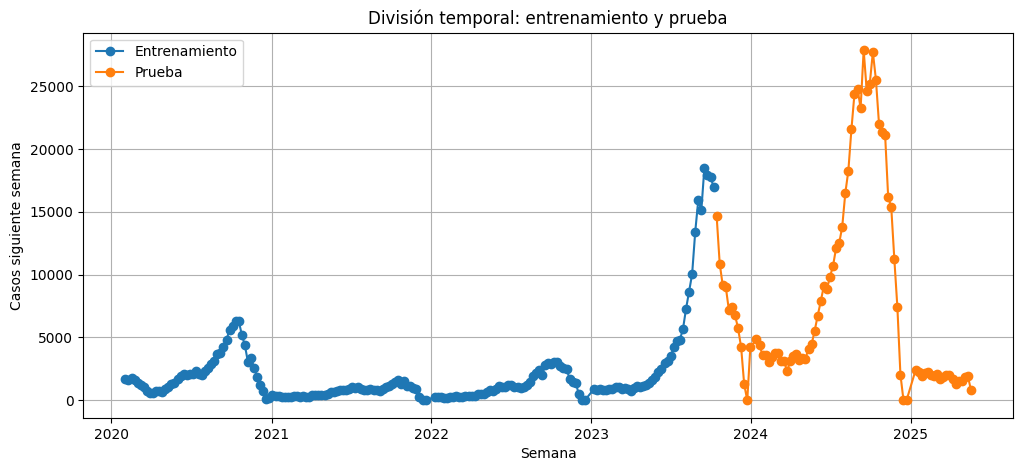

In [59]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_train["semana"],
    df_train["casos_siguiente_semana"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    df_test["semana"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Prueba"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("División temporal: entrenamiento y prueba")
plt.legend()
plt.grid()

plt.show()


In [60]:

df_modelo["riesgo_actual"] = pd.qcut(
    df_modelo["casos_semana"],
    q=3,
    labels=["bajo", "medio", "alto"]
)

In [61]:

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["riesgo_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["riesgo_siguiente_semana"]

df_test["pred_naive"] = df_test["riesgo_actual"]

In [62]:

acc_naive = accuracy_score(y_test, df_test["pred_naive"])

print("Accuracy modelo ingenuo:", acc_naive)

Accuracy modelo ingenuo: 0.9012345679012346


In [63]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, pred_arbol)

print("Accuracy árbol de decisión:", acc_arbol)

Accuracy árbol de decisión: 0.9012345679012346


In [64]:

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.9012345679012346


In [65]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol de decisión",
        "Random Forest"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf
    ]
})

df_metricas

,modelo,accuracy
0,Naive,0.901235
1,Árbol de decisión,0.901235
2,Random Forest,0.901235


In [66]:
labels = ["bajo", "medio", "alto"]

def matriz_confusion_df(y_real, y_pred, labels):
    cm = confusion_matrix(y_real, y_pred, labels=labels)

    df_cm = pd.DataFrame(
        cm,
        index=[f"Real {l}" for l in labels],
        columns=[f"Pred {l}" for l in labels]
    )

    return df_cm

In [67]:
print("Matriz de confusión - Naive")
display(matriz_confusion_df(y_test, df_test["pred_naive"], labels))

print("Matriz de confusión - Árbol")
display(matriz_confusion_df(y_test, pred_arbol, labels))

print("Matriz de confusión - Random Forest")
display(matriz_confusion_df(y_test, pred_rf, labels))

Matriz de confusión - Naive


,Pred bajo,Pred medio,Pred alto
Real bajo,1,3,0
Real medio,0,18,3
Real alto,1,1,54


Matriz de confusión - Árbol


,Pred bajo,Pred medio,Pred alto
Real bajo,1,3,0
Real medio,0,18,3
Real alto,1,1,54


Matriz de confusión - Random Forest


,Pred bajo,Pred medio,Pred alto
Real bajo,1,1,2
Real medio,0,18,3
Real alto,1,1,54


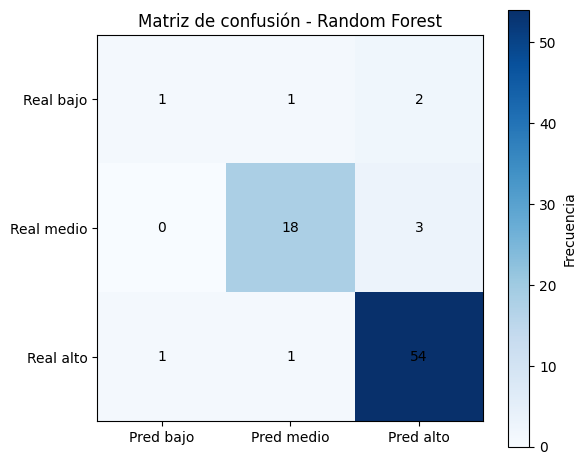

In [68]:
df_cm_rf = matriz_confusion_df(y_test, pred_rf, labels)

plt.figure(figsize=(6, 5))

plt.imshow(df_cm_rf, cmap='Blues')

plt.xticks(range(len(labels)), [f"Pred {l}" for l in labels])
plt.yticks(range(len(labels)), [f"Real {l}" for l in labels])

plt.title("Matriz de confusión - Random Forest")
plt.colorbar(label="Frecuencia")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            df_cm_rf.iloc[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

¿Qué clase se predice mejor?
el riesgo alto
¿Qué clase se confunde más?
el riesgo bajo
¿El modelo detecta bien las semanas de riesgo alto?
en el caso de riesgo alto lo detecta muy bien
¿Confunde semanas de riesgo medio con riesgo bajo o alto?
si, aun que solo confunde el riesgo alto
¿Qué implicaría esto en un contexto epidemiológico?
que el riesgo de infeccion es alto por lo que la cuidadania debe cuidarse

In [69]:
print("Reporte - Árbol de decisión")
print(classification_report(y_test, pred_arbol))

print("Reporte - Random Forest")
print(classification_report(y_test, pred_rf))

Reporte - Árbol de decisión
              precision    recall  f1-score   support

        alto       0.95      0.96      0.96        56
        bajo       0.50      0.25      0.33         4
       medio       0.82      0.86      0.84        21

    accuracy                           0.90        81
   macro avg       0.76      0.69      0.71        81
weighted avg       0.89      0.90      0.89        81

Reporte - Random Forest
              precision    recall  f1-score   support

        alto       0.92      0.96      0.94        56
        bajo       0.50      0.25      0.33         4
       medio       0.90      0.86      0.88        21

    accuracy                           0.90        81
   macro avg       0.77      0.69      0.72        81
weighted avg       0.89      0.90      0.89        81



In [70]:
importancias = pd.DataFrame({
    "variable": variables_predictoras,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
0,casos_semana,0.371547
1,lag_1,0.187138
5,promedio_movil_3,0.169493
6,promedio_movil_5,0.083364
2,lag_2,0.066738
7,cambio_semanal,0.045236
3,lag_3,0.034326
8,cambio_relativo,0.026351
4,lag_4,0.015808


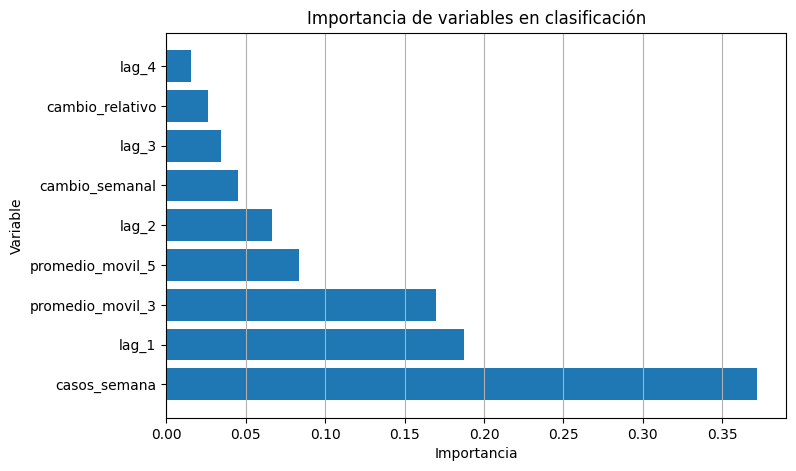

In [71]:
plt.figure(figsize=(8, 5))

plt.barh(
    importancias["variable"],
    importancias["importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables en clasificación")
plt.grid(axis="x")

plt.show()

¿Cuál fue la variable más importante?
la variable mas importante es casos de la semana
¿Los casos actuales (C_t) fueron más importantes que los rezagos?
si, ya que caso_semana es la variable de mayor imporancia
¿Los promedios móviles aportaron información?
si, aportaron informacion importante
¿El cambio semanal fue relevante?
no, ya que su importancia en la grafica es baja
¿La importancia de variables debe interpretarse como causalidad? no ya que al utilizar random forest es un modelo que se acerca mucho a los datos reales

In [72]:
mapa_riesgo = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

df_test["riesgo_real_num"] = df_test["riesgo_siguiente_semana"].map(mapa_riesgo)
df_test["riesgo_rf_num"] = pd.Series(pred_rf, index=df_test.index).map(mapa_riesgo)
df_test["riesgo_naive_num"] = df_test["pred_naive"].map(mapa_riesgo)

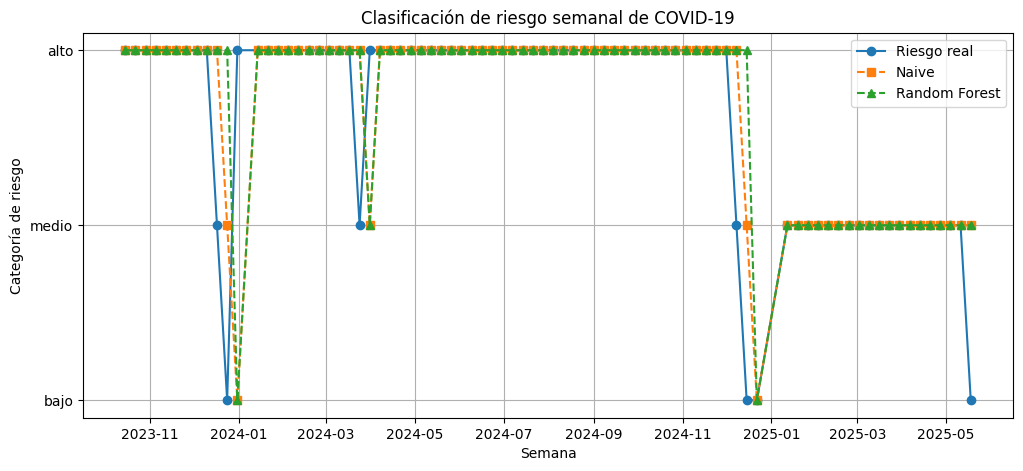

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["semana"],
    df_test["riesgo_real_num"],
    marker="o",
    label="Riesgo real"
)

plt.plot(
    df_test["semana"],
    df_test["riesgo_naive_num"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["semana"],
    df_test["riesgo_rf_num"],
    marker="^",
    linestyle="--",
    label="Random Forest"
)

plt.yticks([0, 1, 2], ["bajo", "medio", "alto"])

plt.xlabel("Semana")
plt.ylabel("Categoría de riesgo")
plt.title("Clasificación de riesgo semanal de COVID-19")
plt.legend()
plt.grid()

plt.show()


¿Cuál fue la variable más importante?

¿Los casos actuales (C_t) fueron más importantes que los rezagos?

¿Los promedios móviles aportaron información?

¿El cambio semanal fue relevante?

¿La importancia de variables debe interpretarse como causalidad?

In [74]:
valores_arboles = [50, 100, 200]
valores_depth = [2, 3, 4, 5, 6]
valores_leaf = [1, 3, 5, 10]

resultados = []

for n_est in valores_arboles:
    for depth in valores_depth:
        for leaf in valores_leaf:

            modelo_temp = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            modelo_temp.fit(X_train, y_train)

            pred_temp = modelo_temp.predict(X_test)

            acc_temp = accuracy_score(y_test, pred_temp)

            resultados.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "accuracy": acc_temp
            })

df_grid = pd.DataFrame(resultados)

df_grid.sort_values("accuracy", ascending=False).head(10)

,n_estimators,max_depth,min_samples_leaf,accuracy
0,50,2,1,0.91358
1,50,2,3,0.91358
2,50,2,5,0.91358
3,50,2,10,0.91358
7,50,3,10,0.91358
11,50,4,10,0.91358
22,100,2,5,0.91358
23,100,2,10,0.91358
27,100,3,10,0.91358
21,100,2,3,0.91358


In [75]:
mejor = df_grid.sort_values("accuracy", ascending=False).iloc[0]

mejor

,0
n_estimators,50.00000
max_depth,2.00000
min_samples_leaf,1.00000
accuracy,0.91358


In [76]:
modelo_rf_final = RandomForestClassifier(
    n_estimators=int(mejor["n_estimators"]),
    max_depth=int(mejor["max_depth"]),
    min_samples_leaf=int(mejor["min_samples_leaf"]),
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

pred_rf_final = modelo_rf_final.predict(X_test)

acc_rf_final = accuracy_score(y_test, pred_rf_final)

print("Random Forest ajustado")
print("Accuracy:", acc_rf_final)

Random Forest ajustado
Accuracy: 0.9135802469135802


In [77]:
df_metricas_final = pd.DataFrame({
    "modelo": [
        "Naive",
        "Árbol",
        "Random Forest inicial",
        "Random Forest ajustado"
    ],
    "accuracy": [
        acc_naive,
        acc_arbol,
        acc_rf,
        acc_rf_final
    ]
})

df_metricas_final.sort_values("accuracy", ascending=False)

,modelo,accuracy
3,Random Forest ajustado,0.913580
0,Naive,0.901235
1,Árbol,0.901235
2,Random Forest inicial,0.901235


In [78]:
df_cm_final = matriz_confusion_df(
    y_test,
    pred_rf_final,
    labels
)

df_cm_final

,Pred bajo,Pred medio,Pred alto
Real bajo,1,1,2
Real medio,0,18,3
Real alto,0,1,55


In [79]:

print(classification_report(y_test, pred_rf_final))

              precision    recall  f1-score   support

        alto       0.92      0.98      0.95        56
        bajo       1.00      0.25      0.40         4
       medio       0.90      0.86      0.88        21

    accuracy                           0.91        81
   macro avg       0.94      0.70      0.74        81
weighted avg       0.92      0.91      0.90        81



¿Qué se observó en la serie nacional de dengue?
en la grafica de los datos realies podemos observar que a mediado del 2023 al 2025 aun que aumenta desde mayo a octubre.

¿Qué modelo funcionó mejor para predecir casos?
el mejor modelo para este caso fue regresion lineal

¿Qué modelo funcionó mejor para clasificar riesgo?
los tres modelos tuvieron una mejor clasificacion

¿El modelo más complejo fue siempre el mejor?
no, ya que los tres tuvieron el mismo margen

¿Qué tan útil fue el modelo ingenuo?
al igual que el resto de modelos tuvo una excelente clasificacion

¿Qué variables fueron más importantes?
los casos de la semana, promedio movil_3 y lag_1

¿Qué limitaciones tiene el análisis?


¿Qué información adicional podría mejorar los modelos?
factores esternos, a que me refieron cuales son las medidas de sanidad se estan tomando